# Trabalho Pratico 1 de Redes Neurais

## Parte 0: Introdução e Imports

Abaixo inicio meu scrpit python chamando a biblioteca numpy. Seu diferencial está em como suas funções foram implementadas, otimizandas de maneira a maximizar o uso vetorial, visto que é execelente para lidar com redes neurais, matrizes e demais estruturas sequenciais.

Objetiva-se resolver um problema de classificação de imagens, usando a Regreção Logistica

Bibliotecas usadas:

- **NumPy**: principal biblioteca de computação científica em Python.

- **Matplotlib**: principal biblioteca para plotagem de gráficos em Python.

- **h5py**: lê conjuntos de dados no formato h5.

- **scipy**: coleção de algoritmos para tarefas como otimização, integração, interpolação, álgebra linear, processamento de sinal, processamento de imagem e estatística.

- **PIL**: testa seu modelo com suas próprias imagens.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image

%matplotlib inline

## Parte 1: Carregar e pré-processar o conjunto de dados

### 1.1 Baixar o conjunto de dados

O conjunto de dados para este projeto contém:

- Treinamento: $n_{tr}$ imagens rotuladas como Gato ($y=1$) ou Não-gato ($y=0$)
- Teste: $n_{te}$ imagens rotuladas como Gato ($y=1$) ou Não-gato ($y=0$)

Todas as imagens são quadradas e coloridas. Portanto, são representadas por arrays numpy no formato `(num_px, num_px, 3)`, onde `num_px` representa a largura e a altura da imagem e 3 se refere aos canais de cor (RGB).


In [2]:
!wget -O 'train_catvnoncat.h5' 'https://raw.githubusercontent.com/lesc-ufv/CCF-482/main/train_catvnoncat.h5'
!wget -O 'test_catvnoncat.h5' 'https://raw.githubusercontent.com/lesc-ufv/CCF-482/main/test_catvnoncat.h5'

train_dataset = h5py.File('train_catvnoncat.h5', "r")
train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # conjunto de imagens de treinamento
train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # rótulos de imagem do conjunto de treinamento

test_dataset = h5py.File('test_catvnoncat.h5', "r")
test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # testando conjunto de imagens
test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # testando rotulos de conjutos de imagens de treinamento

classes = np.array(test_dataset["list_classes"][:]) # lista de classes

train_set_y = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

--2026-04-01 23:22:03--  https://raw.githubusercontent.com/lesc-ufv/CCF-482/main/train_catvnoncat.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2572022 (2.5M) [application/octet-stream]
Saving to: ‘train_catvnoncat.h5’

train_catvnoncat.h5 100%[===================>]   2.45M  11.3MB/s    in 0.2s    

2026-04-01 23:22:04 (11.3 MB/s) - ‘train_catvnoncat.h5’ saved [2572022/2572022]

--2026-04-01 23:22:04--  https://raw.githubusercontent.com/lesc-ufv/CCF-482/main/test_catvnoncat.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6

### 1.2 Visualização de exemplos de conjuntos de dados


Cada linha de `train_set_x_orig` e `test_set_x_orig` é um array numpy representando uma imagem. Você pode visualizar um exemplo executando o seguinte código. Sinta-se à vontade para alterar o valor da variável `index` e executar novamente para ver outras imagens.

y = 1, it's a 'cat' picture.


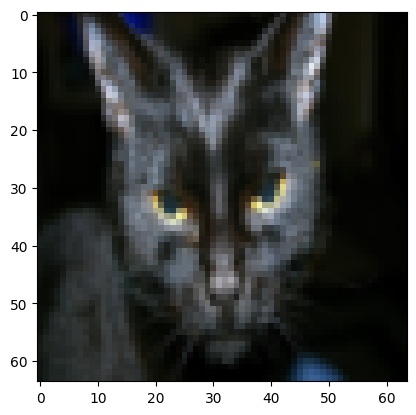

In [3]:
# Plotando uma imagem do conjunto de treinamento
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[0, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

### 1.3 Dimensionalidade do Problema



* Item da lista
* Item da lista

Esta é a primeira célula onde você escreverá o código. Crie as seguintes variáveis:

- `n_train` (número de exemplos de treinamento)
- `n_test` (número de exemplos de teste)
- `num_px` (altura e largura de uma imagem do conjunto de dados)

Use a propriedade `shape` dos arrays NumPy e lembre-se de que `train_set_x_orig` é um array NumPy de formato `(m_train, num_px, num_px, 3)`.

In [4]:
### YOUR CODE STARTS HERE ### (≈3 lines)

n_train = 200 # número de exemplos de treinamento
n_test = 50 # número de exemplos de teste
num_px = 64 # altura e largura de uma imagem do conjunto de dados

### YOUR CODE ENDS HERE ###

print ("Number of training examples: n_train = " + str(n_train))
print ("Number of testing examples: n_test = " + str(n_test))
print ("Height/Width of the images: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: n_train = 200
Number of testing examples: n_test = 50
Height/Width of the images: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


### 1.4 Pré-processamento dos dados


#### 1.4.1 Transformação de imagens em vetores de características

Para processar as imagens do conjunto de dados com regressão logística, precisamos transformá-las em vetores de características. Para isso, vamos achatar essas imagens, originalmente com formato `(num_px, num_px, 3)`, em vetores de formato `(num_px * num_px * 3, 1)`. Use a função `reshape` dos arrays NumPy para modificar o formato das imagens de treinamento `(train_set_x_orig)` e teste `(test_set_x_orig)`. Armazene as imagens de treinamento e teste achatadas em novos arrays chamados `train_set_x_flatten` e `test_set_x_flatten`, respectivamente.


In [5]:
### YOUR CODE STARTS HERE ### (≈2 lines)
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

### YOUR CODE ENDS HERE ###

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))
print ("First 5 features (pixel values) of the first training example: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)
First 5 features (pixel values) of the first training example: [17 31 56 22 33]


#### 1.4.2 Normalizar valores de pixel

Uma etapa muito comum de pré-processamento de imagens em aprendizado de máquina é normalizar os valores dos pixels entre 0 e 1. Para isso, basta dividir cada linha do conjunto de dados por 255 (o valor máximo de um canal de pixel). Divida os arrays `train_set_x_flatten` e `test_set_x_flatten` das imagens achatadas por 255 e armazene os resultados em novos arrays chamados `train_set_x` e `test_set_x`.

In [6]:
### YOUR CODE STARTS HERE ### (≈2 lines)
train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255

### YOUR CODE ENDS HERE ###

print ("First 5 features of the normalized feature vector of the first training example: " + str(train_set_x[0:5,0]))

First 5 features of the normalized feature vector of the first training example: [0.06666667 0.12156863 0.21960784 0.08627451 0.12941176]


## Parte 2: Definindo o Modelo


O modelo que usaremos para classificar imagens de gatos é a regressão logística. Lembre-se de que este modelo tem a seguinte hipótese:

$\hat{y} = h(x) = \sigma(w \cdot x + b)$, onde:

- $x \in R^d$ é um vetor de características;

- $w \in R^d$ é o vetor de pesos (que aprenderemos);

- $b \in R$ é um viés independente de $x$ (que também aprenderemos);

- $w \cdot x$ é o produto escalar de $w$ e $x$;

- $\sigma$ é a função logística ou sigmoide $\frac{1}{1 + e^{-z}}$.

Lembre-se também de que a função de perda para este modelo é a Entropia Cruzada Binária, definida como:

$L(h) = -\frac{1}{m}\sum_{i=1}^{m}(y_i * log\ \hat{y^{(i)}} + (1 - y^{(i)})*log(1 - \hat{y^{(i)}}))$, onde:

- $m$ é o número de exemplos no conjunto de treinamento;

- $y_i$ é o rótulo verdadeiro do exemplo $x_i$;

- $\hat{y^{(i)}}$ é a probabilidade estimada pela função logística de que o exemplo $x^{(i)}$ seja da classe Gato ($y = 1$).

### 2.1 Função Sigmoide


Para tornar seu código mais legível, implemente a função sigmoide independentemente da regressão logística.

In [7]:
def sigmoid(z):
    """
    Computes the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    ### YOUR CODE STARTS HERE ### (≈1 line)
    s = 1/(1 + np.exp(-z))
    ### YOUR CODE ENDS HERE ###

    return s

In [8]:
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid([0, 2]) = [0.5        0.88079708]


### 2.2 Regressão Logística



Usando a função `sigmoid` implementada na etapa anterior e a função `np.dot` do NumPy, implemente a hipótese de regressão logística. Observe que a entrada $X$ é uma matriz, onde cada coluna é um vetor de características $x$ do conjunto de treinamento. Como o NumPy realiza operações vetoriais, você não precisa usar um loop para processar cada linha individualmente; basta executar `logistic_regression(X)`, passando a matriz $X$ como argumento, e o NumPy retornará um vetor de previsões $\hat{Y}$, com uma previsão para cada linha de $X$.

In [9]:
def logistic_regression(X, w, b):
    """
    Computes the logistic regression hypothesis h(x) = sigmoid(wx + b)

    Arguments:
    w -- weights of size (1, num_px * num_px * 3)
    b -- bias (scalar)
    X -- data of size (num_px * num_px * 3, number of examples)

    Return:
    Y_hat -- prediction for each example in X of size (1, number of examples)
    """

    ### YOUR CODE STARTS HERE ### (≈1 line)
    Y_hat = sigmoid(np.dot(w, X) + b)

    ### YOUR CODE ENDS HERE ###

    return Y_hat

In [10]:
w, b, X = np.array([[1.,2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]])
Y_hat = logistic_regression(X, w, b)
print("Y_hat = " + str(Y_hat))

Y_hat = [[0.99987661 0.99999386 0.00449627]]


## Parte 3: Inicializar pesos

Como na regressão logística temos um problema de otimização convexa, podemos inicializar os pesos com zeros ou aleatoriamente. Ao implementar redes neurais artificiais com múltiplas camadas, precisamos ter um pouco mais de cuidado na inicialização dos pesos. Portanto, como forma de preparação para essa etapa futura, você também precisará implementar uma função de inicialização de pesos. Nessa função, você usará a função `np.zeros` para inicializar os pesos da regressão logística com zeros.

In [11]:
def initialize_weights(d):
    """
    Creates a vector of zeros of shape (1, d) for w and initializes b to 0.

    Argument:
    d -- the size of each example in the dataset (num_px * num_px * 3)

    Returns:
    w -- initialized vector of shape (1, d)
    b -- initialized scalar (corresponds to the bias)
    """

    ### YOUR CODE STARTS HERE ### (≈2 lines)
    w = np.zeros((1, d))
    b = 0

    ### YOUR CODE ENDS HERE ###

    assert(w.shape == (1, d))
    assert(isinstance(b, float) or isinstance(b, int))

    return w, b

In [12]:
w, b = initialize_weights(d=2)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0. 0.]]
b = 0


## Parte 4: Definindo uma função de perda



Normalmente, a função de perda escolhida para problemas de classificação binária com regressão logística é a Entropia Cruzada Binária, pois define um problema de otimização convexa. Use a função `np.log` para implementar a Entropia Cruzada Binária para um dado vetor de predição `Y_hat`.

In [13]:
def binary_cross_entropy(Y, Y_hat):
    """
    Computes the binary cross entropy loss.

    Argument:
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (1, number of examples)
    Y_hat -- predictions vector (containing the probability of being cat) of size (1, number of examples)

    Returns:
    loss -- the total loss (scalar) of the predictions Y_hat
    """
    n = Y.shape[1] # Use Y.shape[1] instead of X.shape[1] since X is not defined in this function scope

    ### YOUR CODE STARTS HERE ### (≈1 line)
    loss = -1/n * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    ### YOUR CODE ENDS HERE ###

    return loss

In [14]:
w, b, X, Y = np.array([[1.,2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]), np.array([[1,0,1]])
Y_hat = logistic_regression(X, w, b)
loss = binary_cross_entropy(Y, Y_hat)
print("loss = " + str(loss))

loss = 5.801545319394553


## Parte 5: Calculando o vetor gradiente


Calcule as derivadas parciais `dw` e `db` da entropia cruzada binária $L$ em relação aos pesos `w` e `b` como em:

$$ \frac{\partial L}{\partial w} = \frac{1}{m} (\hat{Y}-Y) \cdot X^T$$
$$ \frac{\partial L}{\partial b} = \frac{1}{m} \sum_{i=1}^m (\hat{y}^{(i)}-y^{(i)})$$

In [15]:
def gradient(X, Y, Y_Hat):
    """
    Computes the gradient of the binary cross entropy loss with respect to the logistic regression weights.

    Arguments:
    X -- data of size (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (1, number of examples)
    Y_hat -- predictions vector (containing the probability of being cat) of size (1, number of examples)

    Returns:
    dw -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b
    """
    n = X.shape[1]

    ### YOUR CODE STARTS HERE ### (≈2 lines)
    dw = 1/n * np.dot(Y_Hat - Y, X.T)
    db = 1/n * np.sum(Y_Hat - Y)
    ### YOUR CODE ENDS HERE ###

    grads = {"dw": dw, "db": db}

    return grads

In [16]:
w, b, X, Y = np.array([[1.,2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]), np.array([[1,0,1]])
Y_hat = logistic_regression(X, w, b)
grads = gradient(X, Y, Y_hat)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

dw = [[0.99845601 2.39507239]]
db = 0.001455578136784208


## Parte 6: Otimizando pesos com descida de gradiente

Use as funções implementadas acima `initialize_weights`, `logistic_regression`, `binary_cross_entropy` e `gradient` para implementar o algoritmo de descida de gradiente e otimizar os pesos $w$ e $b$ da regressão logística.

In [17]:
def optimize(X_train, Y_train, epochs, learning_rate, print_loss = False):
    """
    This function optimizes w and b by running a gradient descent algorithm

    Arguments:
    X -- data of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat), of shape (1, number of examples)
    w -- weights, a numpy array of size (1, num_px * num_px * 3)
    b -- bias, a scalar

    epochs -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_loss -- True to print the loss every 100 steps

    Returns:
    params -- dictionary containing the weights w and bias b
    losses -- list of all the losses computed during the optimization, this will be used to plot the learning curve.
    """
    # Initialize weights
    ### YOUR CODE STARTS HERE ### (≈1 lines)
    w, b = initialize_weights(X_train.shape[0])
    ### YOUR CODE ENDS HERE ###

    losses = []
    for i in range(epochs):
        # Compute Y_hat predictions with logistic regression
        ### YOUR CODE STARTS HERE ### (≈1 line)
        Y_hat = logistic_regression(X_train, w, b)
        ### YOUR CODE ENDS HERE ###

        # Compute the loss for predictions Y_hat
        ### YOUR CODE STARTS HERE ### (≈1 line)
        loss = binary_cross_entropy(Y_train, Y_hat)
        ### YOUR CODE ENDS HERE ###

        # Compute the gradient of your loss function with respect to w and b
        ### YOUR CODE STARTS HERE ### (≈1 line)
        grads = gradient(X_train, Y_train, Y_hat)
        ### YOUR CODE ENDS HERE ###

        # Store partial derivatives from the gradient vector
        dw = grads["dw"]
        db = grads["db"]

        # Update the weights w and b using the gradient descent update rule
        ### YOUR CODE STARTS HERE ### (≈2 lines)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        ### YOUR CODE ENDS HERE ###

        # Store the loss values
        if i % 100 == 0:
            losses.append(loss)

        # Print the loss value after each 100 training iterations
        if print_loss and i % 100 == 0:
            print ("Loss after iteration %i: %f" %(i, loss))

    params = {"w": w, "b": b}

    return params, losses

In [18]:
epochs = 2000
learning_rate = 0.005
params, losses = optimize(train_set_x, train_set_y, epochs, learning_rate, print_loss = False)
w = params["w"]
b = params["b"]
print ("w = " + str(w))
print ("b = " + str(b))

w = [[ 0.00961402 -0.0264683  -0.01226513 ... -0.01144453 -0.02944783
   0.02378106]]
b = -0.015906243999692968


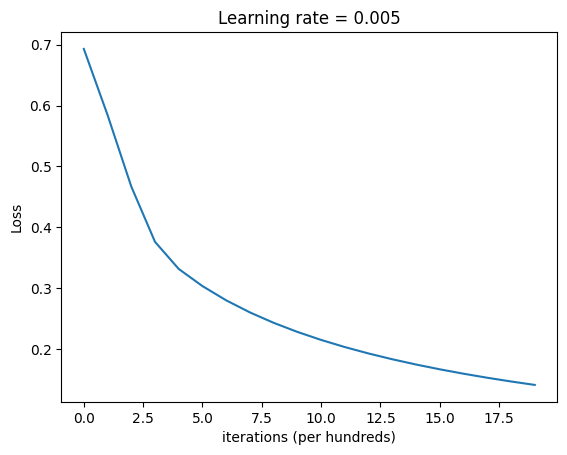

In [19]:
# Plot learning curve
plt.plot(losses)
plt.ylabel('Loss')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate = " + str(learning_rate))
plt.show()

## Parte 7: Avaliando o modelo no conjunto de teste

Finalmente, aplique o limiar $\hat{y} =
\begin{cases}
1,\ \text{se}\ h(x) \geq 0.5\
0,\ \text{se}\ h(x) < 0.5\
\end{cases}$ para classificar todos os exemplos de uma matriz $X$ de exemplos.

In [20]:
def predict(X, w, b):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    w -- weights, a numpy array of size (1, num_px * num_px * 3)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0 or 1) for the examples in X
    '''
    ### YOUR CODE STARTS HERE ### (≈2 lines)
    Y_hat = logistic_regression(X, w, b)
    Y_prediction = (Y_hat >= 0.5).astype(int)
    ### YOUR CODE ENDS HERE ###

    return Y_prediction

In [21]:
Y_prediction_train = predict(train_set_x, w, b)
Y_prediction_test = predict(test_set_x, w, b)

print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - train_set_y)) * 100))
print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - test_set_y)) * 100))

train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


## Parte 8: Aplicando o modelo a dados não vistos

Para testar o modelo com suas imagens fora do set, podemos carregá-las do Google Drive por exemplo:
Abaixo o codigo onde configure a variável `image_path` aponta para o caminho da imagem no Google Drive. Observe que o caminho para o diretório raiz do seu Google Drive é "/content/gdrive/MyDrive/". Portanto, se a sua imagem estiver na raiz do seu Google Drive e se chamar "my_cat.jpg", a variável deverá ser definida como `image_path = /content/gdrive/MyDrive/my_cat.jpg`.


Mounted at /content/gdrive
y = 1, your algorithm predicts a "cat" picture.


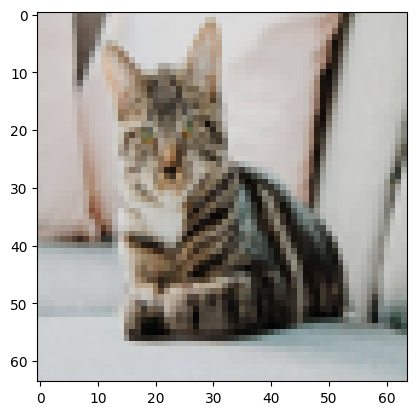

In [22]:
from google.colab import drive
drive.mount('/content/gdrive')

### YOUR CODE STARTS HERE ### (≈1 line)
# Replace this with the actual local path to your image in Google Drive
image_path = "/content/gdrive/MyDrive/RedesNeurais/gato.jpg" # Example: if 'gato.jpg' is in the root of 'My Drive'
### YOUR CODE ENDS HERE ###

# Preprocess the image to fit your algorithm.
with Image.open(image_path) as im:
  low_res_image = np.array(im.resize((num_px, num_px)))

x = low_res_image.reshape((num_px * num_px * 3, 1))
y = predict(x, w, b)

plt.imshow(low_res_image)
print("y = " + str(np.squeeze(y)) + ", your algorithm predicts a \"" + classes[int(np.squeeze(y)),].decode("utf-8") +  "\" picture.")